# Portfolio Construction & Optimization

**Category:** Risk Engineering  
**Project ID:** `risk_01_portfolio_optimization`  

Multi-method covariance estimation (EWMA, Ledoit-Wolf, NCO) with advanced optimizers (MV, Kelly, Risk Parity, Black-Litterman)


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"max_weight": 0.3, "risk_free_rate": 0.04}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                 max_weight: 0.3
             risk_free_rate: 0.04


Data shape: (752, 25)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       GLD       IWM       QQQ       SPY       TLT
count   752.0000  752.0000  752.0000  752.0000  752.0000
mean    189.8027  187.4220  368.3701  444.5639   92.7703
std      26.2586   18.2416   75.2852   68.8578   10.2597
min     151.2300  156.3075  255.2654  341.1821   75.1242
25%     171.2675  172.2746  301.2790  390.6236   86.1116
50%     181.8700  185.0516  357.7935  423.9385   90.5387
75%     211.0475  198.3677  434.0115  500.4846   95.1489
max     257.5000  238.9947  534.5924  598.7401  124.8801


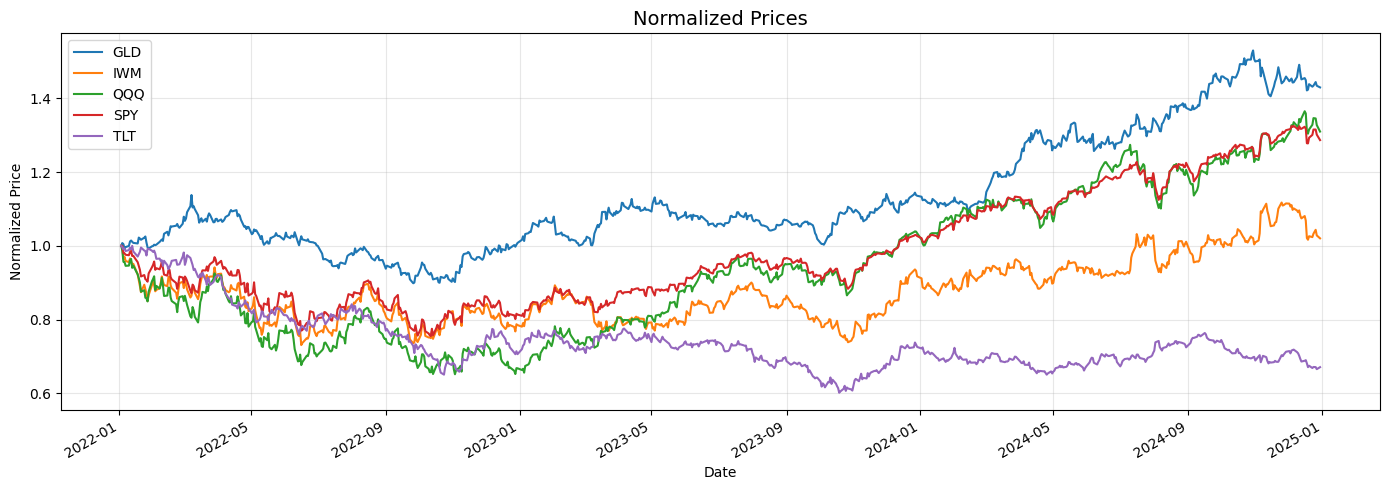

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ['SPY', 'TLT', 'GLD', 'IWM', 'QQQ']
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Portfolio Optimization — MVO vs Risk Parity vs Black-Litterman

Portfolio Weights:

  MVO: Return=11.33%, Vol=14.16%, Sharpe=0.517
    GLD: 37.19%
    IWM: 2.07%
    QQQ: 23.08%
    SPY: 37.19%
    TLT: 0.46%

  Risk Parity: Return=5.43%, Vol=13.17%, Sharpe=0.108
    GLD: 25.71%
    IWM: 16.09%
    QQQ: 15.78%
    SPY: 21.38%
    TLT: 21.04%

  Black-Litterman: Return=11.63%, Vol=14.82%, Sharpe=0.515
    GLD: 34.68%
    IWM: 0.00%
    QQQ: 30.65%
    SPY: 34.68%
    TLT: 0.00%


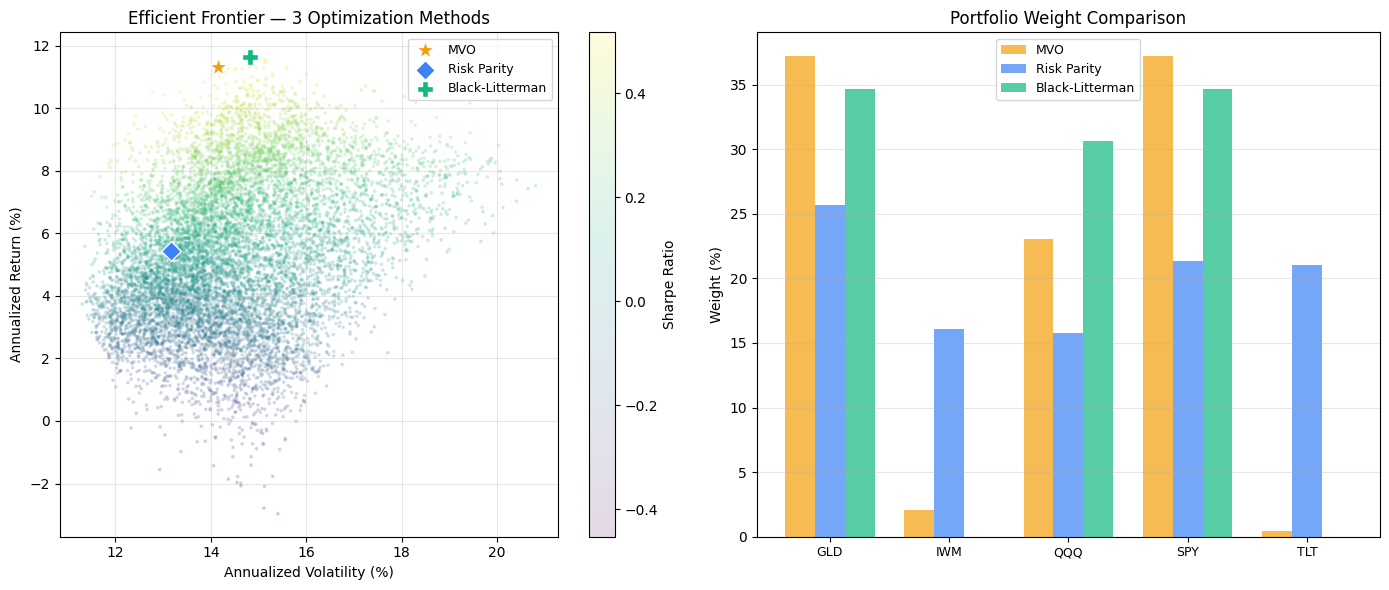

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

returns_df = close.pct_change().dropna()
asset_names = list(close.columns) if close.ndim > 1 else ["Asset"]
n_assets = len(asset_names)

mu = returns_df.mean().values * 252
cov = returns_df.cov().values * 252
rf = PARAMS.get("risk_free_rate", 0.04)
max_w = PARAMS.get("max_weight", 0.3)

rng = np.random.default_rng(SEED)

# --- Method 1: Mean-Variance Optimization (random search) ---
n_portfolios = 10000
results = np.zeros((n_portfolios, 3))
weights_all = []
for i in range(n_portfolios):
    w = rng.random(n_assets); w /= w.sum()
    w = np.clip(w, 0, max_w); w /= w.sum()
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    sr = (ret - rf) / vol if vol > 0 else 0
    results[i] = [vol, ret, sr]
    weights_all.append(w)

mvo_idx = results[:, 2].argmax()
mvo_weights = weights_all[mvo_idx]

# --- Method 2: Risk Parity (inverse-vol) ---
vols = np.sqrt(np.diag(cov))
rp_weights = (1.0 / np.where(vols > 0, vols, 1e-6))
rp_weights = np.clip(rp_weights / rp_weights.sum(), 0, max_w)
rp_weights /= rp_weights.sum()

# --- Method 3: Black-Litterman (simplified) ---
# Market-cap proxy: equal weight as prior, blend with MVO view
tau = 0.05
pi = cov @ (np.ones(n_assets) / n_assets)  # equilibrium returns
P = np.eye(n_assets)  # each asset has a view
Q = mu  # views = historical means
omega = np.diag(np.diag(tau * cov))  # uncertainty

# BL posterior
inv_tau_cov = np.linalg.inv(tau * cov)
inv_omega = np.linalg.inv(omega)
bl_mu = np.linalg.inv(inv_tau_cov + P.T @ inv_omega @ P) @ (inv_tau_cov @ pi + P.T @ inv_omega @ Q)
bl_cov = np.linalg.inv(inv_tau_cov + P.T @ inv_omega @ P)
# Optimal BL weights
bl_weights = np.linalg.solve(cov, bl_mu)
bl_weights = np.clip(bl_weights / bl_weights.sum(), 0, max_w)
bl_weights /= bl_weights.sum()

# Store for later use
portfolio_weights = {"MVO": mvo_weights, "Risk Parity": rp_weights, "Black-Litterman": bl_weights}

print("Portfolio Weights:")
for method, w in portfolio_weights.items():
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    sr = (ret - rf) / vol if vol > 0 else 0
    print(f"\n  {method}: Return={ret:.2%}, Vol={vol:.2%}, Sharpe={sr:.3f}")
    for name, wi in zip(asset_names, w):
        print(f"    {name}: {wi:.2%}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Efficient frontier with 3 portfolios
scatter = axes[0].scatter(results[:, 0]*100, results[:, 1]*100, c=results[:, 2],
                          cmap="viridis", alpha=0.15, s=3)
plt.colorbar(scatter, ax=axes[0], label="Sharpe Ratio")

markers = {"MVO": ("*", "#f59e0b", 200), "Risk Parity": ("D", "#3b82f6", 100),
           "Black-Litterman": ("P", "#10b981", 120)}
for method, (marker, color, sz) in markers.items():
    w = portfolio_weights[method]
    ret, vol = w @ mu, np.sqrt(w @ cov @ w)
    axes[0].scatter(vol*100, ret*100, marker=marker, s=sz, c=color,
                   edgecolors="white", zorder=5, label=method)
axes[0].set_xlabel("Annualized Volatility (%)")
axes[0].set_ylabel("Annualized Return (%)")
axes[0].set_title("Efficient Frontier — 3 Optimization Methods")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Weight comparison bar chart
x = np.arange(n_assets)
width = 0.25
for i, (method, color) in enumerate([("MVO", "#f59e0b"), ("Risk Parity", "#3b82f6"), ("Black-Litterman", "#10b981")]):
    axes[1].bar(x + i*width, portfolio_weights[method]*100, width, label=method, color=color, alpha=0.7)
axes[1].set_xticks(x + width); axes[1].set_xticklabels(asset_names, fontsize=9)
axes[1].set_ylabel("Weight (%)")
axes[1].set_title("Portfolio Weight Comparison")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## Portfolio Backtest

In [5]:
import pandas as pd, numpy as np

returns_df = close.pct_change().dropna()

# Backtest: use MVO weights (static) for equity curve
w = portfolio_weights["MVO"]
strategy_returns_raw = (returns_df.values @ w)
strategy_returns_raw = pd.Series(strategy_returns_raw, index=returns_df.index)
equity_curve = (1 + strategy_returns_raw).cumprod()

# Benchmark: equal-weight
ew_ret = returns_df.mean(axis=1)
benchmark_equity = (1 + ew_ret).cumprod()

print(f"Backtest: {equity_curve.index[0].strftime('%Y-%m-%d')} to {equity_curve.index[-1].strftime('%Y-%m-%d')}")
print(f"MVO final equity: {equity_curve.iloc[-1]:.4f}")
print(f"EW final equity:  {benchmark_equity.iloc[-1]:.4f}")


Backtest: 2022-01-04 to 2024-12-30
MVO final equity: 1.3602
EW final equity:  1.1368


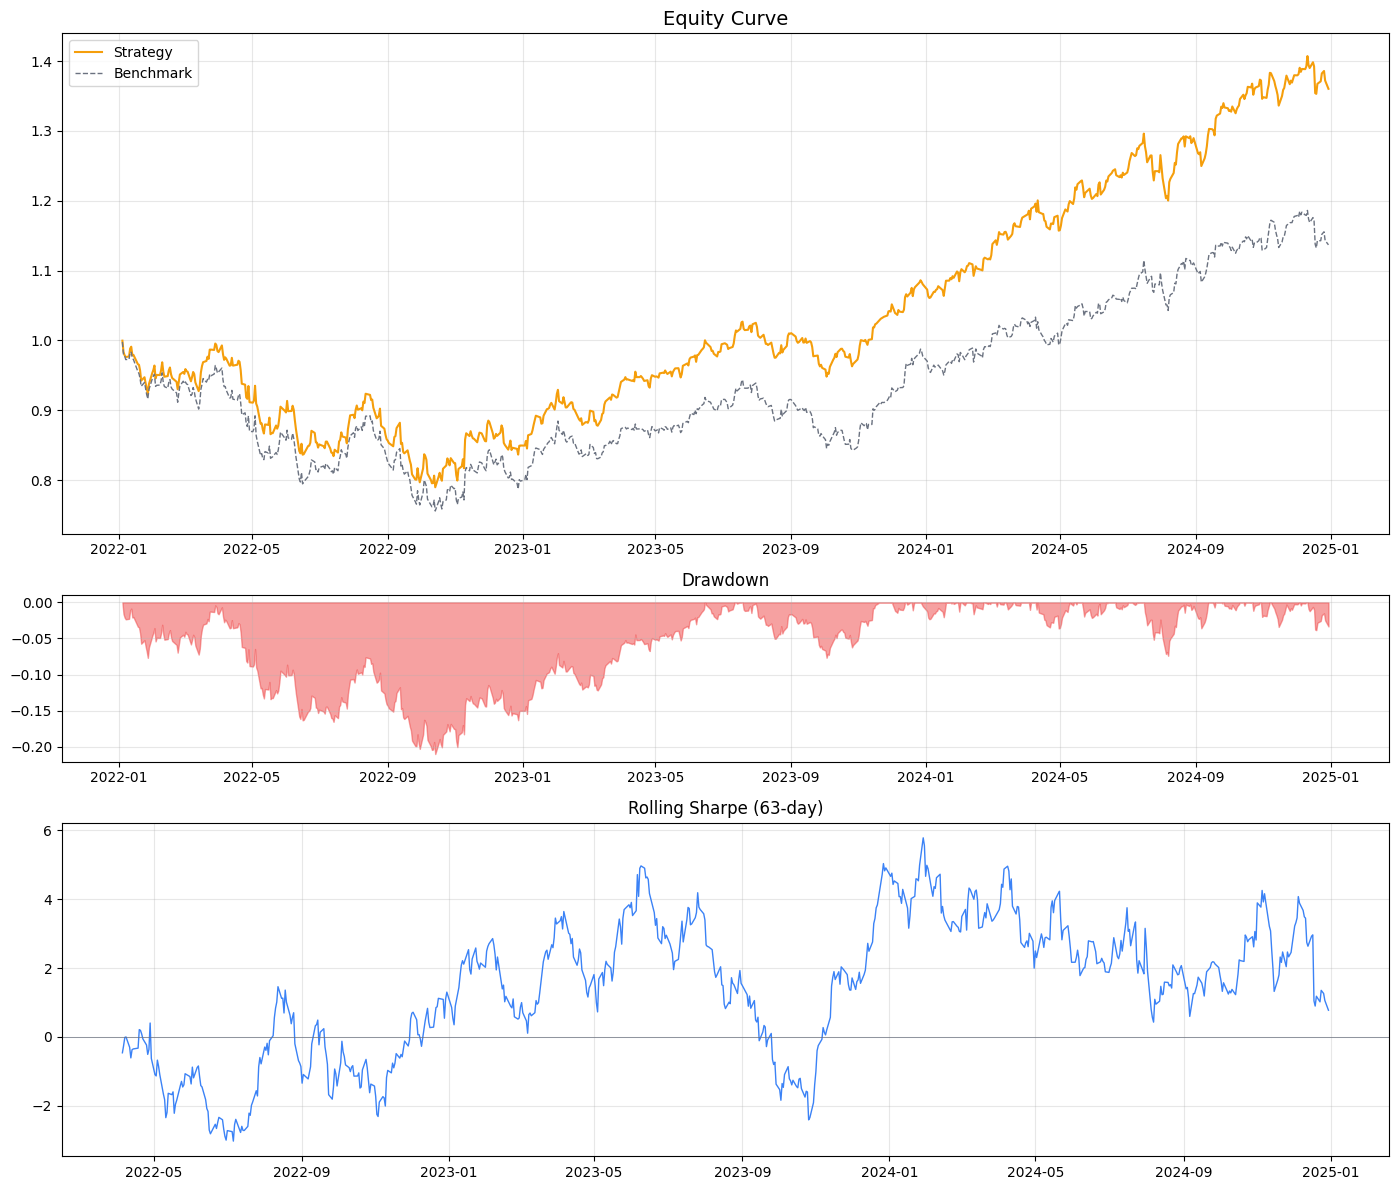

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +36.08%
                       cagr: +10.91%
             annualized_vol: +14.17%
               sharpe_ratio: 0.8014
              sortino_ratio: 1.1499
               calmar_ratio: 0.5274
               max_drawdown: -20.68%
                   win_rate: +53.73%
              profit_factor: 1.1450
               total_trades: 750


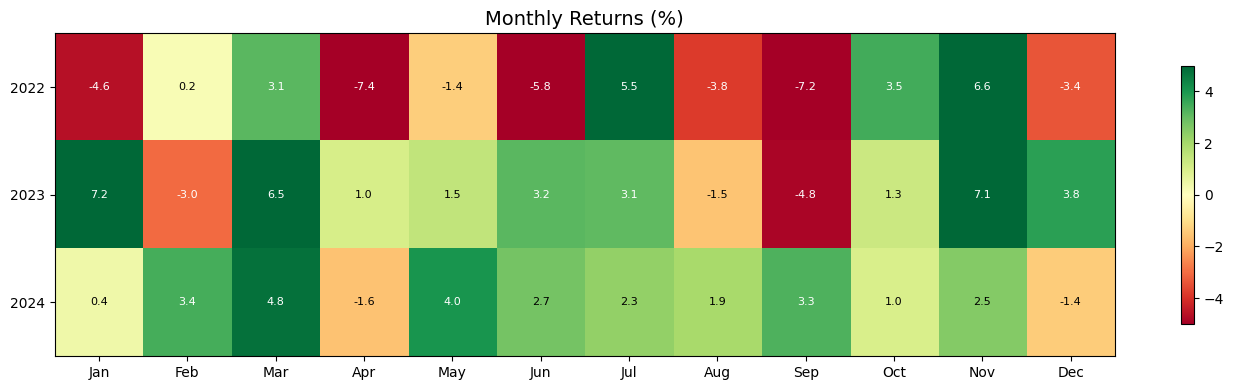

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monthly returns heatmap — requires DatetimeIndex; skipped for synthetic/HFT data
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
except Exception:
    print("Monthly heatmap skipped: equity curve does not have a DatetimeIndex (synthetic data).")
    monthly = None

if monthly is not None:
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="return")
    pivot = pivot.reindex(columns=range(1, 13))  # ensure all 12 months present
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Monthly Returns (%)", fontsize=14)

    # Text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < 0.03 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


In [9]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "risk_01_portfolio_optimization",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Portfolio Construction & Optimization

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
